### Customer Churn Prediction — Phase 2: Preprocessing + Model Comparison
### Telco Customer Churn Dataset
 
Steps:
  1. Load & preprocess with ColumnTransformer + Pipeline
  2. Logistic Regression, Random Forest, XGBoost
  3. StratifiedKFold cross-validation comparison
  4. Best model evaluation on held-out test set
  5. Save best model predictions for Phase 3 (SHAP)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     cross_validate)
from sklearn.metrics import (roc_auc_score, f1_score, precision_score,
                             recall_score, accuracy_score,
                             confusion_matrix, ConfusionMatrixDisplay,
                             classification_report, RocCurveDisplay,
                             precision_recall_curve, average_precision_score)
import warnings
warnings.filterwarnings("ignore")
 
plt.rcParams.update({"figure.facecolor": "white", "axes.spines.top": False,
                     "axes.spines.right": False, "axes.grid": True,
                     "grid.color": "#e5e5e5"})
 
SEED = 42

### LOAD AND PREPARE DATA

In [2]:
df = pd.read_csv("telco_clean.csv")
 
# Drop columns not useful for modelling
df = df.drop(columns=["customerID", "TenureBand"], errors="ignore")
 
# Target
y = (df["Churn"] == "Yes").astype(int)
X = df.drop(columns=["Churn", "ChurnBinary"], errors="ignore")
 
print("=" * 60)
print("PHASE 2 — PREPROCESSING + MODEL COMPARISON")
print("=" * 60)
print(f"Features  : {X.shape[1]}")
print(f"Samples   : {len(X):,}")
print(f"Churn rate: {y.mean()*100:.1f}%")
 
# ── Feature groups ────────────────────────────────────────────────────────
NUMERICAL = ["tenure", "MonthlyCharges", "TotalCharges"]
 
BINARY_CATS = ["gender", "Partner", "Dependents", "PhoneService",
               "MultipleLines", "OnlineSecurity", "OnlineBackup",
               "DeviceProtection", "TechSupport", "StreamingTV",
               "StreamingMovies", "PaperlessBilling", "SeniorCitizen"]
BINARY_CATS = [c for c in BINARY_CATS if c in X.columns]
 
MULTI_CATS = ["InternetService", "Contract", "PaymentMethod"]
MULTI_CATS = [c for c in MULTI_CATS if c in X.columns]

PHASE 2 — PREPROCESSING + MODEL COMPARISON
Features  : 19
Samples   : 7,043
Churn rate: 26.5%


### PREPROCESSING PIPELINE

In [3]:
# Numeric: impute median → scale
num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
])
 
# Binary categoricals: map Yes/No → 1/0 then impute
# Easier to handle via OHE with drop="if_binary"
bin_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(drop="if_binary", sparse_output=False,
                              handle_unknown="ignore")),
])
 
# Multi-class categoricals: one-hot encode
multi_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(drop="first", sparse_output=False,
                              handle_unknown="ignore")),
])
 
preprocessor = ColumnTransformer([
    ("num",   num_pipe,   NUMERICAL),
    ("bin",   bin_pipe,   BINARY_CATS),
    ("multi", multi_pipe, MULTI_CATS),
])
 
# Quick check — transform and count features
X_check = preprocessor.fit_transform(X)
print(f"\nAfter preprocessing: {X_check.shape[1]} features")
print(f"  Numeric    : {len(NUMERICAL)}")
print(f"  Binary cats: {len(BINARY_CATS)} → {X_check.shape[1] - len(NUMERICAL) - len(MULTI_CATS)*2} encoded")
print(f"  Multi cats : {len(MULTI_CATS)} → remainder")


After preprocessing: 37 features
  Numeric    : 3
  Binary cats: 13 → 28 encoded
  Multi cats : 3 → remainder


### TRAIN AND TEST SPLIT

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)
 
print(f"\nTrain: {len(X_train):,}  |  Test: {len(X_test):,}")
print(f"Train churn rate: {y_train.mean()*100:.1f}%  "
      f"|  Test churn rate: {y_test.mean()*100:.1f}%")


Train: 5,634  |  Test: 1,409
Train churn rate: 26.5%  |  Test churn rate: 26.5%


###  DEFINE MODELS

In [6]:
models = {
    "Logistic Regression": Pipeline([
        ("pre",   preprocessor),
        ("model", LogisticRegression(
            max_iter=1000, class_weight="balanced", random_state=SEED)),
    ]),
    "Random Forest": Pipeline([
        ("pre",   preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=200, class_weight="balanced",
            random_state=SEED, n_jobs=-1)),
    ]),
    "Gradient Boosting": Pipeline([
        ("pre",   preprocessor),
        ("model", GradientBoostingClassifier(
            n_estimators=200, learning_rate=0.05,
            max_depth=4, random_state=SEED)),
    ]),
    "XGBoost": Pipeline([
        ("pre",   preprocessor),
        ("model", XGBClassifier(
            n_estimators=300, learning_rate=0.05,
            max_depth=5, subsample=0.8,
            colsample_bytree=0.8,
            scale_pos_weight=(y_train==0).sum() / (y_train==1).sum(),
            random_state=SEED, eval_metric="logloss",
            verbosity=0)),
    ]),
}

### STRATIFIED K-FOLD CROSS VALIDATION

In [7]:
cv      = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
SCORING = ["roc_auc", "f1", "precision", "recall", "accuracy"]
 
cv_results = {}
print(f"\nRunning 5-fold stratified cross-validation...\n")
 
for name, pipe in models.items():
    scores = cross_validate(pipe, X_train, y_train,
                            cv=cv, scoring=SCORING,
                            return_train_score=False)
    cv_results[name] = {
        "AUC-ROC"  : scores["test_roc_auc"].mean(),
        "F1"       : scores["test_f1"].mean(),
        "Precision": scores["test_precision"].mean(),
        "Recall"   : scores["test_recall"].mean(),
        "Accuracy" : scores["test_accuracy"].mean(),
        "AUC Std"  : scores["test_roc_auc"].std(),
    }
    print(f"  {name:<22}  AUC={cv_results[name]['AUC-ROC']:.4f} "
          f"± {cv_results[name]['AUC Std']:.4f}  "
          f"F1={cv_results[name]['F1']:.4f}  "
          f"Recall={cv_results[name]['Recall']:.4f}")
 
cv_df = (pd.DataFrame(cv_results).T
           .sort_values("AUC-ROC", ascending=False)
           .round(4))
 
print(f"\n{'='*65}")
print("CV COMPARISON TABLE  (sorted by AUC-ROC)")
print(f"{'='*65}")
print(cv_df.drop(columns=["AUC Std"]).to_string())
 
best_name = cv_df.index[0]
print(f"\n✓ Best model: {best_name}")


Running 5-fold stratified cross-validation...

  Logistic Regression     AUC=0.8459 ± 0.0125  F1=0.6292  Recall=0.8013
  Random Forest           AUC=0.8235 ± 0.0097  F1=0.6028  Recall=0.6421
  Gradient Boosting       AUC=0.8461 ± 0.0117  F1=0.5823  Recall=0.5244
  XGBoost                 AUC=0.8407 ± 0.0106  F1=0.6334  Recall=0.7492

CV COMPARISON TABLE  (sorted by AUC-ROC)
                     AUC-ROC      F1  Precision  Recall  Accuracy
Gradient Boosting     0.8461  0.5823     0.6557  0.5244    0.8007
Logistic Regression   0.8459  0.6292     0.5183  0.8013    0.7496
XGBoost               0.8407  0.6334     0.5487  0.7492    0.7700
Random Forest         0.8235  0.6028     0.5682  0.6421    0.7756

✓ Best model: Gradient Boosting


### CV COMPARISON BAR CHART

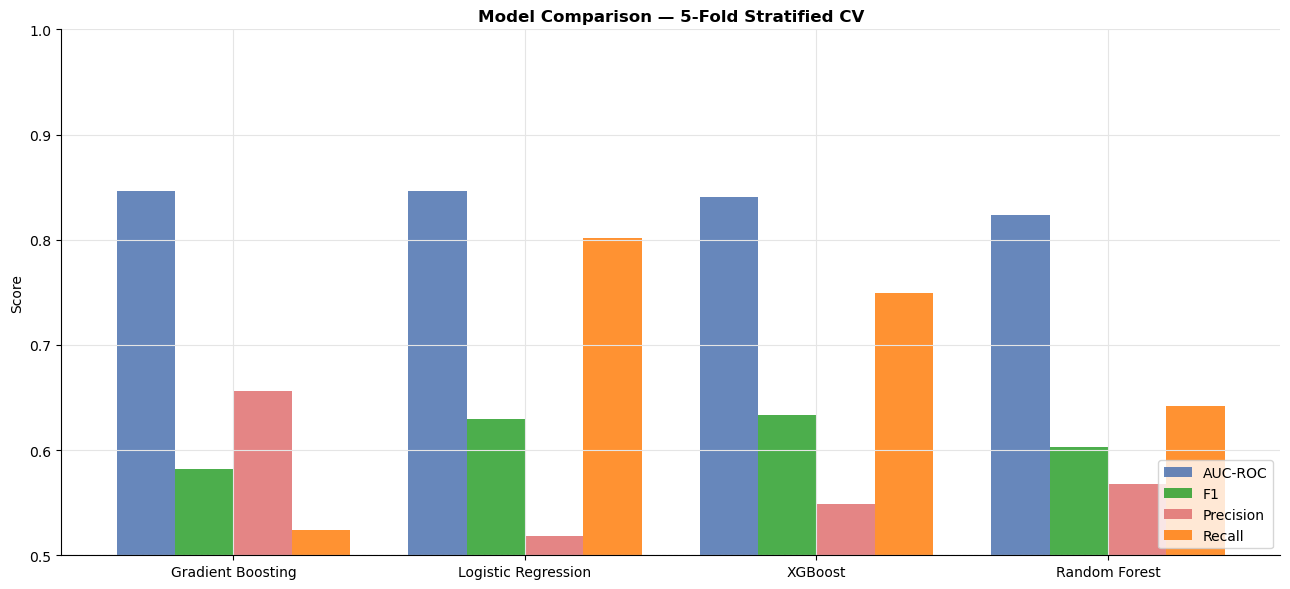

In [8]:
metrics     = ["AUC-ROC", "F1", "Precision", "Recall"]
model_names = cv_df.index.tolist()
x = np.arange(len(model_names))
w = 0.2
 
fig, ax = plt.subplots(figsize=(13, 6))
bar_colors = ["#4C72B0", "#2ca02c", "#E07070", "#FF7F0E"]
 
for i, metric in enumerate(metrics):
    vals = cv_df[metric].values
    bars = ax.bar(x + i*w, vals, w, label=metric,
                  color=bar_colors[i], alpha=0.85)
 
ax.set_xticks(x + w*1.5)
ax.set_xticklabels(model_names, fontsize=10)
ax.set_ylabel("Score")
ax.set_ylim(0.5, 1.0)
ax.set_title("Model Comparison — 5-Fold Stratified CV",
             fontweight="bold", fontsize=12)
ax.legend(fontsize=10, loc="lower right")
ax.axhline(0.5, color="#ccc", linestyle="--", linewidth=0.8)
 
plt.tight_layout()
plt.savefig("phase2_cv_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

### FIT BEST MODEL ON FULL TRAIN SET — EVALUATE ON TEST

In [10]:
# Fit all models (needed for ROC curves and confusion matrices)
fitted = {}
for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    fitted[name] = pipe
 
best_pipe = fitted[best_name]
y_pred    = best_pipe.predict(X_test)
y_prob    = best_pipe.predict_proba(X_test)[:, 1]
 
print(f"\nTest set results — {best_name}:")
print(classification_report(y_test, y_pred,
                             target_names=["Retained","Churned"]))


Test set results — Gradient Boosting:
              precision    recall  f1-score   support

    Retained       0.84      0.91      0.88      1035
     Churned       0.68      0.53      0.60       374

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.74      1409
weighted avg       0.80      0.81      0.80      1409



### ROC CURVES — ALL MODELS

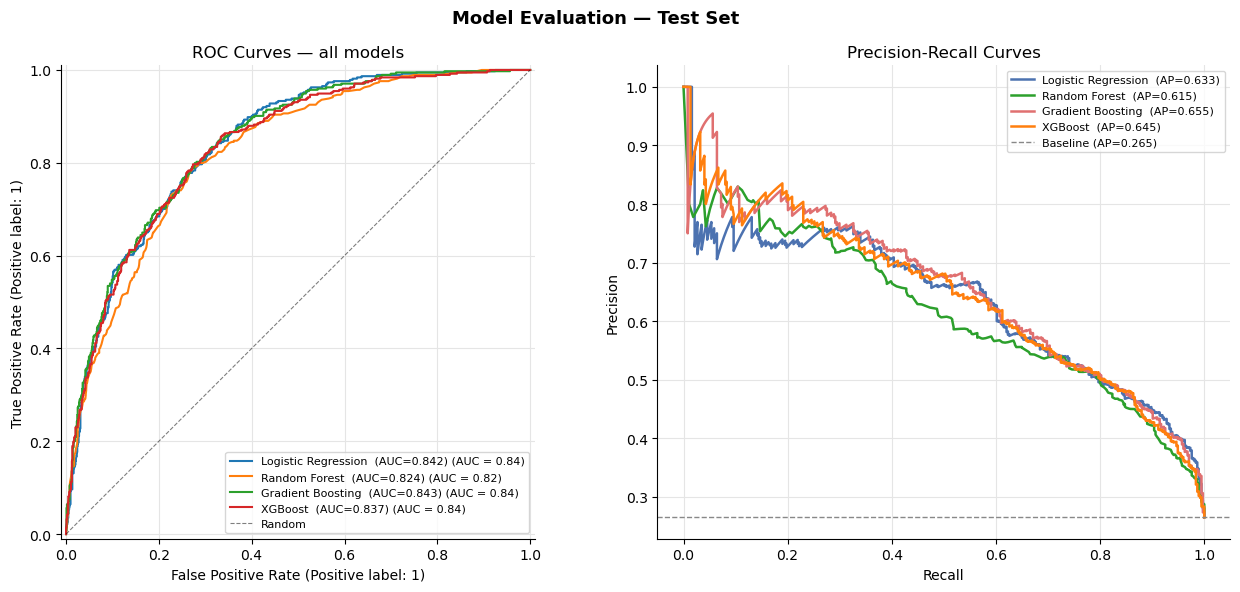

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
fig.suptitle("Model Evaluation — Test Set", fontweight="bold", fontsize=13)
 
# ROC curves
ax = axes[0]
roc_colors = ["#4C72B0", "#2ca02c", "#E07070", "#FF7F0E"]
for (name, pipe), color in zip(fitted.items(), roc_colors):
    y_p = pipe.predict_proba(X_test)[:, 1]
    RocCurveDisplay.from_predictions(y_test, y_p,
                                      name=f"{name}  (AUC={roc_auc_score(y_test,y_p):.3f})",
                                      ax=ax)
ax.plot([0,1],[0,1],"k--",linewidth=0.8,alpha=0.5,label="Random")
ax.set_title("ROC Curves — all models")
ax.legend(fontsize=8, loc="lower right")
 
# PR curves
ax2 = axes[1]
for (name, pipe), color in zip(fitted.items(), roc_colors):
    y_p = pipe.predict_proba(X_test)[:, 1]
    prec_c, rec_c, _ = precision_recall_curve(y_test, y_p)
    ap = average_precision_score(y_test, y_p)
    ax2.plot(rec_c, prec_c, color=color, linewidth=1.8,
             label=f"{name}  (AP={ap:.3f})")
ax2.axhline(y_test.mean(), color="#888", linestyle="--",
            linewidth=1, label=f"Baseline (AP={y_test.mean():.3f})")
ax2.set_xlabel("Recall")
ax2.set_ylabel("Precision")
ax2.set_title("Precision-Recall Curves")
ax2.legend(fontsize=8, loc="upper right")
 
plt.tight_layout()
plt.savefig("phase2_roc_pr_curves.png", dpi=150, bbox_inches="tight")
plt.show()

### THRESHOLD TUNING — BEST MODEL


Threshold tuning — Gradient Boosting:
 Threshold  Precision  Recall    F1  FN  FP
      0.10      0.407   0.930 0.566  26 508
      0.15      0.449   0.890 0.597  41 408
      0.20      0.483   0.834 0.612  62 334
      0.25      0.513   0.786 0.621  80 279
      0.30      0.527   0.735 0.614  99 247
      0.35      0.572   0.687 0.625 117 192
      0.40      0.598   0.639 0.618 135 161
      0.45      0.629   0.586 0.607 155 129
      0.50      0.683   0.535 0.600 174  93
      0.55      0.691   0.455 0.548 204  76
      0.60      0.731   0.385 0.504 230  53
      0.65      0.763   0.310 0.441 258  36
      0.70      0.789   0.259 0.390 277  26
      0.75      0.817   0.179 0.294 307  15
      0.80      0.786   0.118 0.205 330  12
      0.85      0.814   0.094 0.168 339   8
      0.90      0.909   0.027 0.052 364   1

  Best F1 at threshold = 0.35  (F1=0.625  Recall=0.687  FN=117)


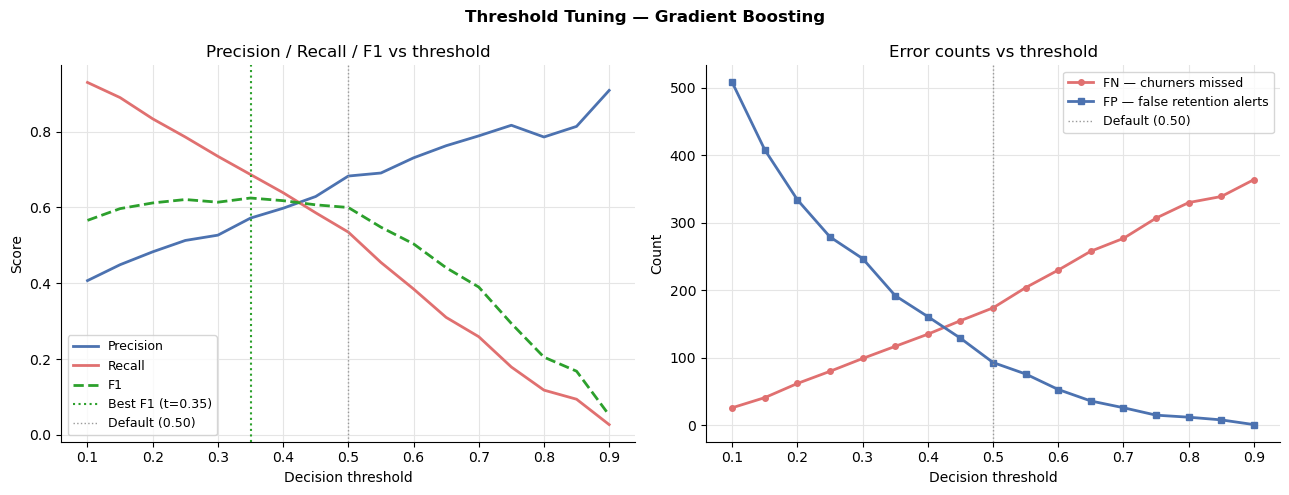

In [13]:
thresh_range = np.arange(0.10, 0.91, 0.05)
thresh_rows  = []
 
for t in thresh_range:
    y_pred_t = (y_prob >= t).astype(int)
    cm_t     = confusion_matrix(y_test, y_pred_t)
    tn, fp, fn, tp = cm_t.ravel()
    thresh_rows.append({
        "Threshold": round(t, 2),
        "Precision": round(precision_score(y_test, y_pred_t, zero_division=0), 3),
        "Recall"   : round(recall_score(y_test, y_pred_t, zero_division=0), 3),
        "F1"       : round(f1_score(y_test, y_pred_t, zero_division=0), 3),
        "FN"       : int(fn),
        "FP"       : int(fp),
    })
 
thresh_df   = pd.DataFrame(thresh_rows)
best_f1_idx = thresh_df["F1"].idxmax()
 
print(f"\nThreshold tuning — {best_name}:")
print(thresh_df.to_string(index=False))
print(f"\n  Best F1 at threshold = "
      f"{thresh_df.loc[best_f1_idx,'Threshold']:.2f}  "
      f"(F1={thresh_df.loc[best_f1_idx,'F1']:.3f}  "
      f"Recall={thresh_df.loc[best_f1_idx,'Recall']:.3f}  "
      f"FN={thresh_df.loc[best_f1_idx,'FN']})")
 
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f"Threshold Tuning — {best_name}", fontweight="bold")
 
ax = axes[0]
ax.plot(thresh_df["Threshold"], thresh_df["Precision"],
        color="#4C72B0", linewidth=2, label="Precision")
ax.plot(thresh_df["Threshold"], thresh_df["Recall"],
        color="#E07070", linewidth=2, label="Recall")
ax.plot(thresh_df["Threshold"], thresh_df["F1"],
        color="#2ca02c", linewidth=2, linestyle="--", label="F1")
ax.axvline(thresh_df.loc[best_f1_idx,"Threshold"],
           color="#2ca02c", linestyle=":", linewidth=1.5,
           label=f"Best F1 (t={thresh_df.loc[best_f1_idx,'Threshold']:.2f})")
ax.axvline(0.5, color="#999", linestyle=":", linewidth=1, label="Default (0.50)")
ax.set_xlabel("Decision threshold")
ax.set_ylabel("Score")
ax.set_title("Precision / Recall / F1 vs threshold")
ax.legend(fontsize=9)
 
ax2 = axes[1]
ax2.plot(thresh_df["Threshold"], thresh_df["FN"],
         color="#E07070", linewidth=2, marker="o",
         markersize=4, label="FN — churners missed")
ax2.plot(thresh_df["Threshold"], thresh_df["FP"],
         color="#4C72B0", linewidth=2, marker="s",
         markersize=4, label="FP — false retention alerts")
ax2.axvline(0.5, color="#999", linestyle=":", linewidth=1, label="Default (0.50)")
ax2.set_xlabel("Decision threshold")
ax2.set_ylabel("Count")
ax2.set_title("Error counts vs threshold")
ax2.legend(fontsize=9)
 
plt.tight_layout()
plt.savefig("phase2_threshold_tuning.png", dpi=150, bbox_inches="tight")
plt.show()

### SAVED PREDICTIONS FOR SHAP ANALYSIS

In [14]:
best_test_auc = roc_auc_score(y_test, y_prob)
best_test_f1  = f1_score(y_test, y_pred)
best_test_rec = recall_score(y_test, y_pred)
best_test_fn  = confusion_matrix(y_test, y_pred)[1, 0]
 
print(f"\n{'='*60}\nPHASE 2 SUMMARY\n{'='*60}")
print(f"  Best model  : {best_name}")
print(f"  CV AUC-ROC  : {cv_df.loc[best_name,'AUC-ROC']:.4f} "
      f"± {cv_df.loc[best_name,'AUC Std']:.4f}")
print(f"  Test AUC-ROC: {best_test_auc:.4f}")
print(f"  Test F1     : {best_test_f1:.4f}")
print(f"  Test Recall : {best_test_rec:.4f}")
print(f"  Test FN     : {best_test_fn}  churners missed at default threshold")
print(f"  Best F1 threshold: {thresh_df.loc[best_f1_idx,'Threshold']:.2f}  "
      f"→ FN={thresh_df.loc[best_f1_idx,'FN']}")
 
print("\nSaved:")
print("  phase2_cv_comparison.png")
print("  phase2_roc_pr_curves.png")
print("  phase2_confusion_matrices.png")
print("  phase2_threshold_tuning.png")
print("  churn_test_predictions.csv")
print("  churn_train_preprocessed.csv")
print("\nNext: Phase 3 — SHAP explainability")


PHASE 2 SUMMARY
  Best model  : Gradient Boosting
  CV AUC-ROC  : 0.8461 ± 0.0117
  Test AUC-ROC: 0.8432
  Test F1     : 0.5997
  Test Recall : 0.5348
  Test FN     : 174  churners missed at default threshold
  Best F1 threshold: 0.35  → FN=117

Saved:
  phase2_cv_comparison.png
  phase2_roc_pr_curves.png
  phase2_confusion_matrices.png
  phase2_threshold_tuning.png
  churn_test_predictions.csv
  churn_train_preprocessed.csv

Next: Phase 3 — SHAP explainability
